# Non-Financial Time-Series Forecasting Case Study (SARIMAX)

In [1]:
!pip install pmdarima --quiet


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import warnings
warnings.filterwarnings("ignore")
import os
os.environ["PYTHONWARNINGS"] = "ignore"

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import pmdarima as pm

from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.holtwinters import ExponentialSmoothing

RANDOM_STATE = 42
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

## 1. Load data and perform a minimal global audit

In [3]:
path = "non_financial_ts_sarimax_case.csv"
df_raw = pd.read_csv(path, parse_dates=["date"])

print("Raw shape:", df_raw.shape)
print("Date range:", df_raw["date"].min(), "to", df_raw["date"].max())
print("Duplicate rows:", int(df_raw.duplicated().sum()))
print("Missing values by column:")
display(df_raw.isna().sum().to_frame("missing_count").T)
print("Dtypes:")
display(df_raw.dtypes.astype(str).to_frame("dtype").T)

Raw shape: (145, 7)
Date range: 2014-01-01 00:00:00 to 2025-12-01 00:00:00
Duplicate rows: 1
Missing values by column:


,date,passengers_thousands,search_interest_index,ticket_price_index,weather_severity_index,strike_dummy,shock_dummy
missing_count,0,0,4,0,0,0,0


Dtypes:


,date,passengers_thousands,search_interest_index,ticket_price_index,weather_severity_index,strike_dummy,shock_dummy
dtype,datetime64[us],float64,float64,float64,float64,int64,int64


In [4]:
summary_table = pd.DataFrame({
    "min": df_raw.drop(columns=["date"]).min(numeric_only=True),
    "max": df_raw.drop(columns=["date"]).max(numeric_only=True),
    "mean": df_raw.drop(columns=["date"]).mean(numeric_only=True),
    "std": df_raw.drop(columns=["date"]).std(numeric_only=True),
})
display(summary_table)

,min,max,mean,std
passengers_thousands,91.21,722.26,350.690552,177.525182
search_interest_index,91.57,140.15,115.581560,10.667362
ticket_price_index,98.59,114.48,106.683586,4.748792
weather_severity_index,-2.37,2.02,-0.006483,1.094190
strike_dummy,0.00,1.00,0.020690,0.142837
shock_dummy,0.00,1.00,0.048276,0.215092


This is a monthly series of 144 observations (12 years) with 6 potential covariates. One duplicate row, 4 missing values in search_interest_index — both minor.

Key observation: this is a non-financial series, so I am not starting from the prior that the level is stationary. Trend, seasonality and structural breaks are likely first-order objects rather than nuisances.

Intentionally simple cleaning: sort chronologically, drop the one duplicate, linearly interpolate the 4 missing search_interest values. No smoothing — the forecasting problem is precisely about preserving level and seasonal structure.

In [5]:
df = df_raw.sort_values("date").drop_duplicates().reset_index(drop=True).copy()
df["search_interest_index"] = df["search_interest_index"].interpolate(limit_direction="both")
print("Post-cleaning shape:", df.shape)

Post-cleaning shape: (144, 7)


## 2. Reserve a final holdout before detailed EDA

In [6]:
holdout_size = 24
dev_df = df.iloc[:-holdout_size].copy()
holdout_df = df.iloc[-holdout_size:].copy()

display(pd.DataFrame({
    "sample": ["development", "final_holdout"],
    "rows": [len(dev_df), len(holdout_df)],
    "start_date": [dev_df["date"].min(), holdout_df["date"].min()],
    "end_date": [dev_df["date"].max(), holdout_df["date"].max()],
}))

,sample,rows,start_date,end_date
0,development,120,2014-01-01,2023-12-01
1,final_holdout,24,2024-01-01,2025-12-01


## 3. EDA on the development sample only

### 3.1 Level series and potential drivers

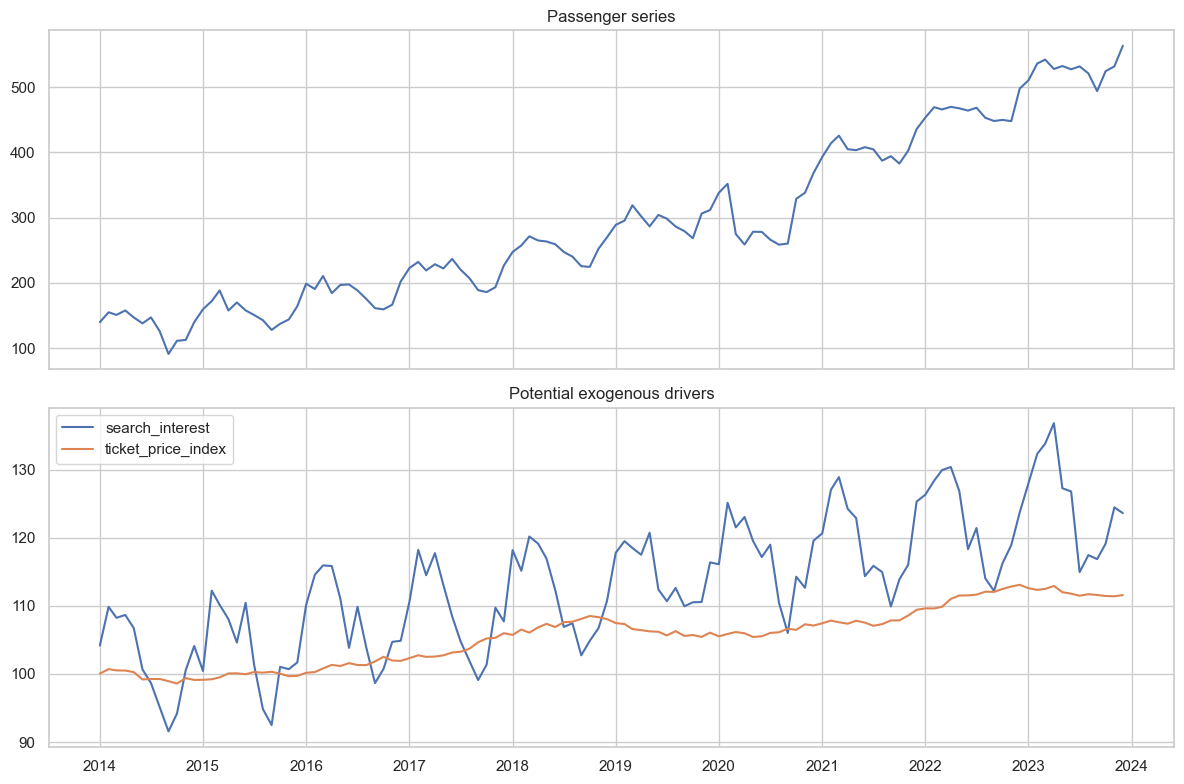

In [7]:
%matplotlib inline

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axes[0].plot(dev_df["date"], dev_df["passengers_thousands"], label="passengers")
axes[0].set_title("Passenger series")
axes[1].plot(dev_df["date"], dev_df["search_interest_index"], label="search_interest")
axes[1].plot(dev_df["date"], dev_df["ticket_price_index"], label="ticket_price_index")
axes[1].legend()
axes[1].set_title("Potential exogenous drivers")
plt.tight_layout()
plt.show();

Three features are immediately visible: (1) a clear upward trend, (2) strong annual seasonality with amplitude that grows with the level, and (3) a sharp structural break around 2020. The growing seasonal amplitude suggests **multiplicative** seasonality — I will test both additive and multiplicative specifications.

### 3.2 Seasonal decomposition

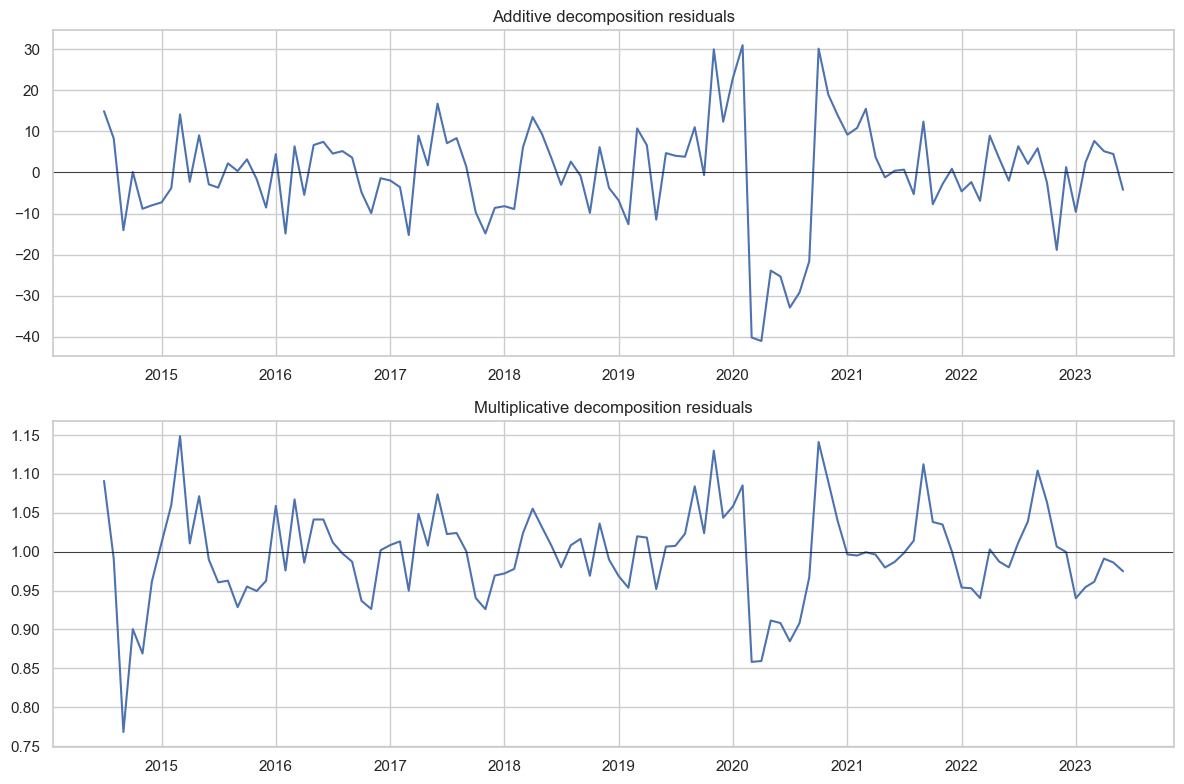

Additive residual std: 12.43
Multiplicative residual std: 0.0603


In [8]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

decomp_add = sm.tsa.seasonal_decompose(dev_df.set_index("date")["passengers_thousands"], model="additive", period=12)
decomp_mult = sm.tsa.seasonal_decompose(dev_df.set_index("date")["passengers_thousands"], model="multiplicative", period=12)

axes[0].plot(decomp_add.resid.dropna(), label="additive residuals")
axes[0].set_title("Additive decomposition residuals")
axes[0].axhline(0, color="black", lw=0.5)

axes[1].plot(decomp_mult.resid.dropna(), label="multiplicative residuals")
axes[1].set_title("Multiplicative decomposition residuals")
axes[1].axhline(1, color="black", lw=0.5)

plt.tight_layout()
plt.show()

print("Additive residual std:", round(decomp_add.resid.dropna().std(), 2))
print("Multiplicative residual std:", round(decomp_mult.resid.dropna().std(), 4))

Two arguments point in different directions. The **additive** decomposition has a lower relative residual std (12.43 / 350 ≈ 3.6%) compared to the **multiplicative** (0.060 / 1.0 = 6.0%), meaning it captures slightly more variance in aggregate.

However, the multiplicative residuals are visibly more **homoscedastic** — their variance stays roughly constant over time, whereas the additive residuals fan out as the level grows. For forecasting, constant-variance residuals matter more than a marginally lower global std, because they produce confidence intervals with more uniform coverage across the forecast horizon.

Combined with the visual evidence from §3.1 (seasonal amplitude clearly grows with the level), this supports treating seasonality as multiplicative — either via Holt-Winters multiplicative or via a log-transform of the SARIMAX target. Time permitting, it would be worth testing SARIMAX on both `passengers` and `log(passengers)` to quantify the impact; the log-transform would convert the multiplicative structure into an additive one that ARIMA handles natively.

### 3.3 Stationarity tests

In [9]:
adf_level = adfuller(dev_df["passengers_thousands"])
adf_diff = adfuller(dev_df["passengers_thousands"].diff().dropna())
adf_diff_seasonal = adfuller(dev_df["passengers_thousands"].diff().diff(12).dropna())

display(pd.DataFrame({
    "series": ["level", "first_difference (d=1)", "first_diff + seasonal_diff (d=1, D=1)"],
    "adf_stat": [adf_level[0], adf_diff[0], adf_diff_seasonal[0]],
    "p_value": [adf_level[1], adf_diff[1], adf_diff_seasonal[1]],
}))

,series,adf_stat,p_value
0,level,2.248769,0.998920
1,first_difference (d=1),-2.472073,0.122418
2,"first_diff + seasonal_diff (d=1, D=1)",-4.530088,0.000173


--> ADF on levels fails to reject H0 (p=0.999). First differencing alone is marginal (p=0.122) — the seasonal component adds persistent autocorrelation that a single difference does not remove. After both regular and seasonal differencing, ADF rejects decisively (p=0.0002), confirming that **(d=1, D=1)** is the right differencing specification.

### 3.4 ACF/PACF of differenced series

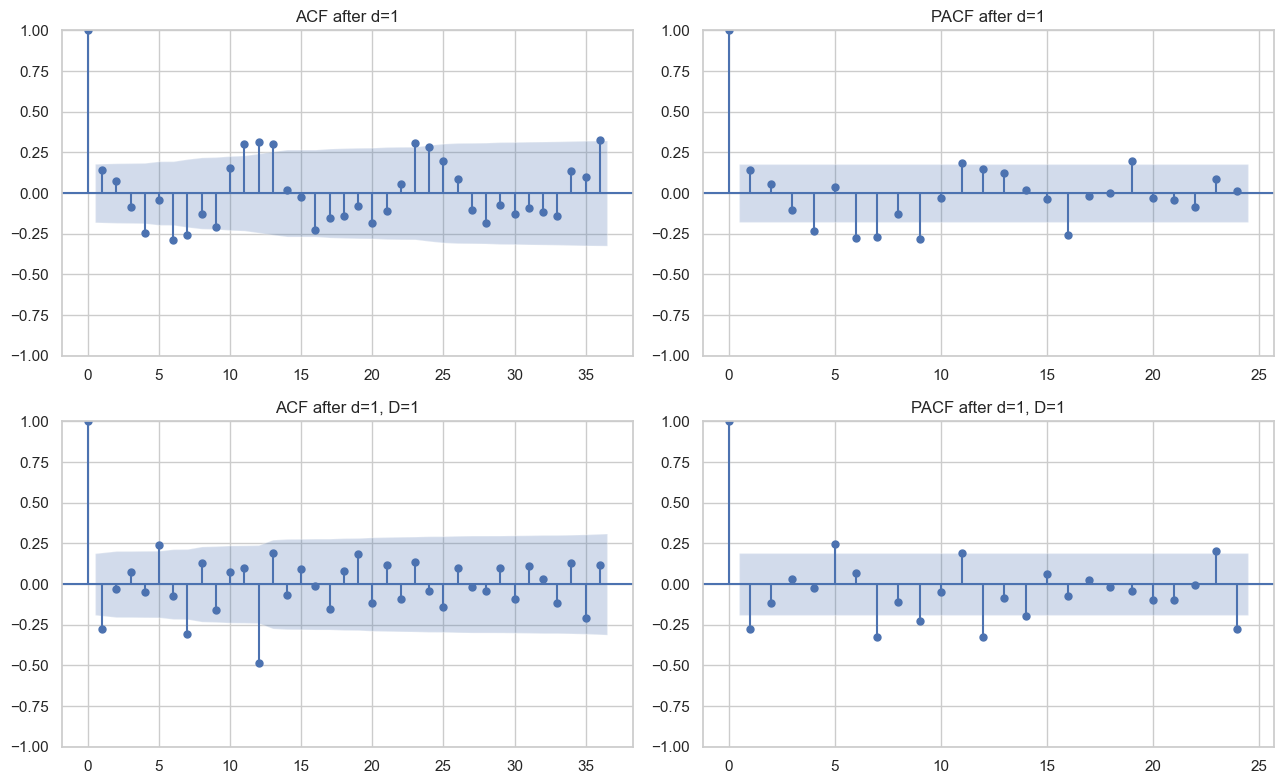

In [10]:
# Apply both regular and seasonal differencing before inspecting ACF/PACF
y = dev_df["passengers_thousands"]
y_diff = y.diff().dropna()  # d=1
y_diff_seasonal = y_diff.diff(12).dropna()  # D=1, s=12

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
plot_acf(y_diff, lags=36, ax=axes[0, 0], title="ACF after d=1")
plot_pacf(y_diff, lags=24, ax=axes[0, 1], title="PACF after d=1")
plot_acf(y_diff_seasonal, lags=36, ax=axes[1, 0], title="ACF after d=1, D=1")
plot_pacf(y_diff_seasonal, lags=24, ax=axes[1, 1], title="PACF after d=1, D=1")
plt.tight_layout()
plt.show()

After single differencing (top row), strong spikes remain at lags 12, 24, 36 — confirming the need for seasonal differencing. After both d=1 and D=1 (bottom row), significant spikes persist at lag 1 and lag 12 in both ACF and PACF, confirming that there is temporal structure beyond what differencing alone removes.

Interpreting ACF/PACF for seasonal ARIMA is notoriously subjective — different analysts could read these same plots as (0,1,1)(0,1,1,12), (1,1,1)(1,1,1,12), or other specifications. Rather than committing to a manual order, I use `pmdarima.auto_arima` in §4 to systematically select the ARIMA and seasonal orders via AIC minimization. The ACF/PACF analysis confirms that the series has enough residual structure to justify a SARIMA model, which is the key diagnostic conclusion.

### 3.5 Exogenous variable inspection

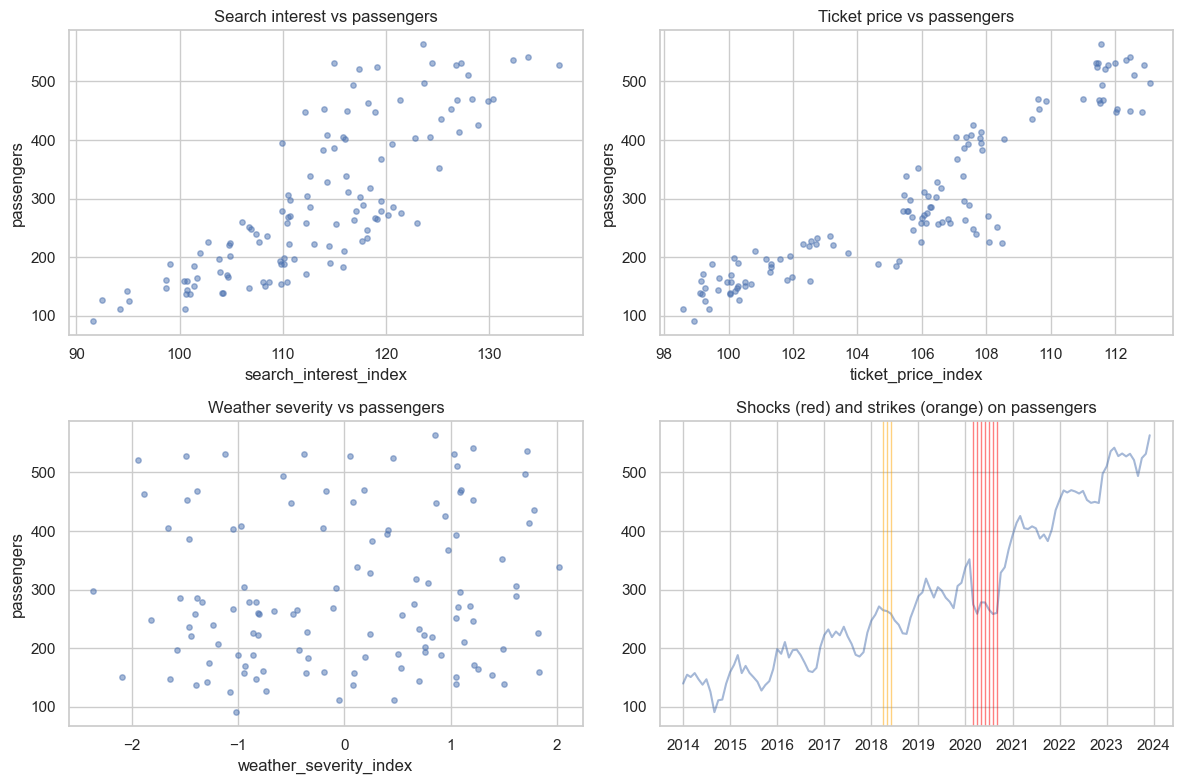

,corr_with_passengers
search_interest_index,0.810468
ticket_price_index,0.923545
weather_severity_index,0.106849


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0,0].scatter(dev_df["search_interest_index"], dev_df["passengers_thousands"], alpha=0.5, s=15)
axes[0,0].set_xlabel("search_interest_index"); axes[0,0].set_ylabel("passengers")
axes[0,0].set_title("Search interest vs passengers")

axes[0,1].scatter(dev_df["ticket_price_index"], dev_df["passengers_thousands"], alpha=0.5, s=15)
axes[0,1].set_xlabel("ticket_price_index"); axes[0,1].set_ylabel("passengers")
axes[0,1].set_title("Ticket price vs passengers")

axes[1,0].scatter(dev_df["weather_severity_index"], dev_df["passengers_thousands"], alpha=0.5, s=15)
axes[1,0].set_xlabel("weather_severity_index"); axes[1,0].set_ylabel("passengers")
axes[1,0].set_title("Weather severity vs passengers")

# Shock/strike timing
axes[1,1].plot(dev_df["date"], dev_df["passengers_thousands"], alpha=0.5)
shock_dates = dev_df.loc[dev_df["shock_dummy"] == 1, "date"]
strike_dates = dev_df.loc[dev_df["strike_dummy"] == 1, "date"]
for d in shock_dates: axes[1,1].axvline(d, color="red", alpha=0.5, lw=1)
for d in strike_dates: axes[1,1].axvline(d, color="orange", alpha=0.5, lw=1)
axes[1,1].set_title("Shocks (red) and strikes (orange) on passengers")

plt.tight_layout()
plt.show()

# Correlations with passengers
corr_with_y = dev_df[["passengers_thousands"] + ["search_interest_index", "ticket_price_index", "weather_severity_index"]].corr()["passengers_thousands"].drop("passengers_thousands")
display(corr_with_y.to_frame("corr_with_passengers"))

Search interest (r=0.81) and ticket price (r=0.92) both show strong positive correlations with passengers — but these are almost certainly spurious, driven by shared upward trends. Weather severity (r=0.11) shows near-zero raw correlation. The shock dummy aligns precisely with the 2020 collapse.

The raw correlations are misleading. What matters is whether these variables explain variation *beyond* trend and seasonality.

### 3.6 Exogenous signal after removing trend: differenced residuals

The raw correlations between exogenous variables and passengers are dominated by shared trends. To assess whether the exogenous variables carry genuine predictive information, I difference both passengers and the continuous exogenous variables (first difference is sufficient for the exogenous since they do not have strong seasonality) and check the correlation of the residuals.

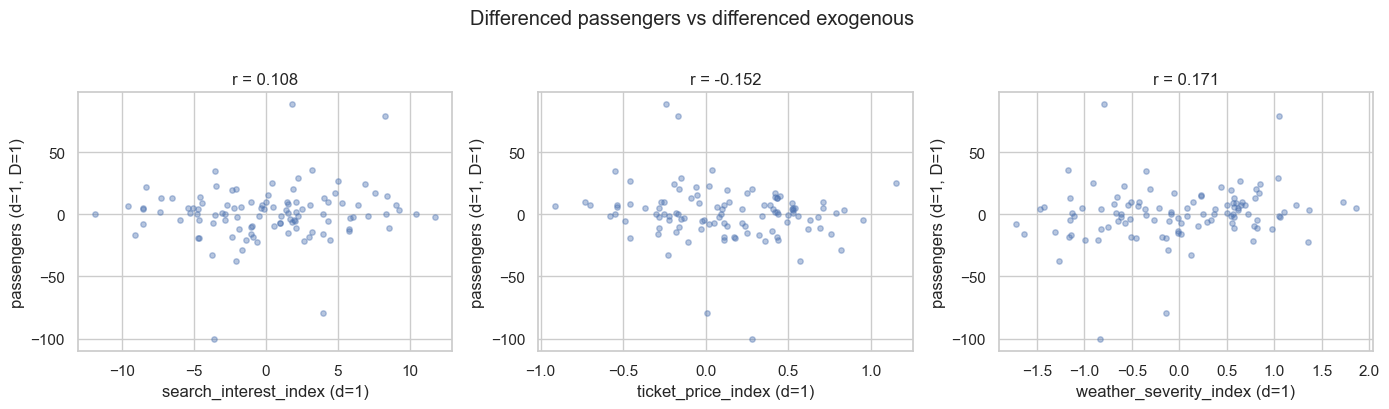

Detrended correlations:
  search_interest_index: 0.108
  ticket_price_index: -0.152
  weather_severity_index: 0.171


In [12]:
# Difference passengers (d=1 + D=1) and exogenous (d=1 only, no seasonality to remove)
y_dd = dev_df["passengers_thousands"].diff().diff(12).dropna()
exog_continuous = ["search_interest_index", "ticket_price_index", "weather_severity_index"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
detrended_corrs = {}

for ax, col in zip(axes, exog_continuous):
    x_d = dev_df[col].diff().dropna()
    # Align indices
    common_idx = y_dd.index.intersection(x_d.index)
    y_aligned = y_dd.loc[common_idx]
    x_aligned = x_d.loc[common_idx]
    
    corr = y_aligned.corr(x_aligned)
    detrended_corrs[col] = round(corr, 3)
    
    ax.scatter(x_aligned, y_aligned, alpha=0.4, s=15)
    ax.set_xlabel(f"{col} (d=1)")
    ax.set_ylabel("passengers (d=1, D=1)")
    ax.set_title(f"r = {corr:.3f}")

plt.suptitle("Differenced passengers vs differenced exogenous", y=1.02)
plt.tight_layout()
plt.show()

print("Detrended correlations:")
for k, v in detrended_corrs.items():
    print(f"  {k}: {v}")

After detrending, the correlations drop dramatically: search_interest falls from 0.81 to 0.11, ticket_price from 0.92 to -0.15. Both are now negligible. Weather severity is the only continuous variable with a modest detrended correlation (0.17), suggesting it may carry some genuine incremental signal.

This confirms that the exogenous value in the SARIMAX comes primarily from the binary intervention variables (shock_dummy, strike_dummy), not from the continuous covariates. The continuous variables track the same trend as passengers but do not explain deviations from it.

### 3.7 Exogenous significance after detrending

In [13]:
# OLS on double-differenced target vs differenced continuous exog + dummies in levels
sig_df = dev_df.copy()

sig_df["y_dd"] = sig_df["passengers_thousands"].diff().diff(12)
for col in ["search_interest_index", "ticket_price_index", "weather_severity_index"]:
    sig_df[f"{col}_d"] = sig_df[col].diff()

sig_df = sig_df.dropna()

ols_formula = (
    "y_dd ~ search_interest_index_d + ticket_price_index_d"
    " + weather_severity_index_d + strike_dummy + shock_dummy"
)
ols_exog = smf.ols(formula=ols_formula, data=sig_df).fit(cov_type="HC3")
print(ols_exog.summary())

                            OLS Regression Results                            
Dep. Variable:                   y_dd   R-squared:                       0.071
Model:                            OLS   Adj. R-squared:                  0.025
Method:                 Least Squares   F-statistic:                     1.226
Date:                Thu, 28 May 2026   Prob (F-statistic):              0.303
Time:                        16:40:00   Log-Likelihood:                -477.47
No. Observations:                 107   AIC:                             966.9
Df Residuals:                     101   BIC:                             983.0
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

This OLS tests whether the exogenous variables have any linear association with the target after removing trend and seasonality via double differencing (d=1, D=1). Continuous exogenous variables are also differenced (d=1) to avoid spurious regression from shared trends. The binary dummies are kept in levels since they are already stationary.

**No variable is significant** (all p > 0.10), and the F-test rejects nothing (p = 0.30, R² = 0.07). Even `shock_dummy` is non-significant (p = 0.54). This is not necessarily surprising: the OLS works on the *differenced* series, where a sustained level shift only appears as entry/exit spikes — a 0/1 dummy is not well suited to capture that in differences.

`ticket_price_index_d` comes closest (p = 0.10, coef = −7.57). `weather_severity_index_d` shows a positive but non-significant association (p = 0.16).

This OLS is intentionally conservative. A non-significant result here means no *obvious* marginal signal after detrending, but it does not rule out that these variables could be useful in a model that operates on levels rather than differences — the ARIMA error structure could amplify weak signals that a simple OLS on differences cannot detect.

## 4. Order selection and modeling setup

In [14]:
exog_cols = ["search_interest_index", "ticket_price_index",
             "weather_severity_index", "strike_dummy", "shock_dummy"]

train_df = dev_df.copy()
covid_mask = (train_df["date"] >= "2020-03-01") & (train_df["date"] <= "2021-06-01")
train_no_covid = train_df[~covid_mask].copy()
final_holdout_df = holdout_df.copy()

print("Train:", len(train_df), "| Train excl. COVID:", len(train_no_covid),
      "| Holdout:", len(final_holdout_df))

Train: 120 | Train excl. COVID: 104 | Holdout: 24


I use `pmdarima.auto_arima` to systematically select the SARIMAX order via AIC minimization, with d=1 and D=1 fixed (validated by the stationarity tests in §3.3). The search is exhaustive (`stepwise=False`) to avoid the greedy path-dependency of the default stepwise approach. I run it on both the full training set and the COVID-excluded training set, to check whether COVID changes the optimal order.

In [15]:
# ── auto_arima on full training set (exhaustive search) ──
auto_full = pm.auto_arima(
    train_df["passengers_thousands"], exogenous=train_df[exog_cols],
    seasonal=True, m=12, d=1, D=1,
    start_p=0, max_p=2, start_q=0, max_q=2,
    start_P=0, max_P=1, start_Q=0, max_Q=1,
    stepwise=False, n_jobs=-1,
    suppress_warnings=True, error_action="ignore"
)
print(f"auto_arima (full train): {auto_full.order} x {auto_full.seasonal_order}, AIC={auto_full.aic():.1f}")

# ── auto_arima on COVID-excluded training set (exhaustive search) ──
auto_no_covid = pm.auto_arima(
    train_no_covid["passengers_thousands"], exogenous=train_no_covid[exog_cols],
    seasonal=True, m=12, d=1, D=1,
    start_p=0, max_p=2, start_q=0, max_q=2,
    start_P=0, max_P=1, start_Q=0, max_Q=1,
    stepwise=False, n_jobs=-1,
    suppress_warnings=True, error_action="ignore"
)
print(f"auto_arima (excl. COVID): {auto_no_covid.order} x {auto_no_covid.seasonal_order}, AIC={auto_no_covid.aic():.1f}")

auto_arima (full train): (0, 1, 1) x (1, 1, 0, 12), AIC=931.6
auto_arima (excl. COVID): (2, 1, 0) x (0, 1, 1, 12), AIC=767.2


The exhaustive search selects **(0,1,1)(1,1,0,12)** on the full train (AIC = 931.6) and **(2,1,0)(0,1,1,12)** on the COVID-excluded train (AIC = 767.2). The structures are strikingly different: the full-train model uses MA(1) + seasonal AR(1), while the COVID-excluded model uses AR(2) + seasonal MA(1). This confirms that COVID does not just affect parameter values — it changes the model structure.

The AIC gap (931.6 vs 767.2) also reflects the noisier likelihood surface when COVID outliers are included. The COVID-excluded model achieves a much tighter fit on cleaner data.

## 5. Model selection via rolling-origin CV

Rather than selecting the best model on the holdout (which would contaminate its role as final evaluation), I use rolling-origin cross-validation on the development set. Each fold trains on data up to a cutoff and forecasts the next 12 months. The model with the lowest average RMSE across folds is selected, and only that model is formally evaluated on the holdout in §8.

In [16]:
full_df = pd.concat([train_df, final_holdout_df], ignore_index=True)

rolling_results = []
for cutoff in range(48, len(full_df) - 12, 12):
    sub_train = full_df.iloc[:cutoff]
    sub_test = full_df.iloc[cutoff:cutoff + 12]
    actual = sub_test["passengers_thousands"].values
    fold_label = sub_train["date"].max().strftime("%Y-%m")

    covid_mask = (sub_train["date"] >= "2020-03-01") & (sub_train["date"] <= "2021-06-01")
    sub_clean = sub_train[~covid_mask] if (~covid_mask).sum() > 24 else sub_train

    # ── SARIMAX variants ──
    sarimax_specs = [
        ("SARIMAX with COVID + exog",     sub_train, auto_full.order,     auto_full.seasonal_order,     True),
        ("SARIMAX with COVID (no exog)",   sub_train, auto_full.order,     auto_full.seasonal_order,     False),
        ("SARIMAX excl. COVID + exog",     sub_clean, auto_no_covid.order, auto_no_covid.seasonal_order, True),
        ("SARIMAX excl. COVID (no exog)",  sub_clean, auto_no_covid.order, auto_no_covid.seasonal_order, False),
    ]
    for label, tr, order, sorder, use_exog in sarimax_specs:
        try:
            endog = tr["passengers_thousands"].copy()
            endog.index = pd.date_range(start=tr["date"].iloc[0], periods=len(tr), freq="MS")
            exog_tr, exog_te = None, None
            if use_exog:
                exog_tr = tr[exog_cols].copy(); exog_tr.index = endog.index
                exog_te = sub_test[exog_cols].copy()
                exog_te.index = pd.date_range(start=sub_test["date"].iloc[0], periods=12, freq="MS")
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                fit = sm.tsa.statespace.SARIMAX(endog, exog=exog_tr, order=order, seasonal_order=sorder,
                    enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, maxiter=200, method="lbfgs")
                pred = fit.get_forecast(steps=12, exog=exog_te).predicted_mean.values
            rolling_results.append({"fold": fold_label, "model": label, "rmse": round(rmse(actual, pred), 1)})
        except:
            rolling_results.append({"fold": fold_label, "model": label, "rmse": np.nan})

    # ── Holt-Winters ──
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            hw_fold = ExponentialSmoothing(sub_train["passengers_thousands"], trend="mul", seasonal="mul",
                seasonal_periods=12, use_boxcox=False, initialization_method="estimated").fit(optimized=True)
        rolling_results.append({"fold": fold_label, "model": "Holt-Winters", "rmse": round(rmse(actual, hw_fold.forecast(12).values), 1)})
    except:
        rolling_results.append({"fold": fold_label, "model": "Holt-Winters", "rmse": np.nan})

    # ── Baselines ──
    naive = full_df.set_index("date")["passengers_thousands"].shift(12).loc[sub_test["date"]].values
    rolling_results.append({"fold": fold_label, "model": "seasonal_naive", "rmse": round(rmse(actual, naive), 1)})
    lv = np.repeat(sub_train["passengers_thousands"].iloc[-1], 12)
    rolling_results.append({"fold": fold_label, "model": "last_value", "rmse": round(rmse(actual, lv), 1)})

rolling_df = pd.DataFrame(rolling_results)
pivot = rolling_df.pivot(index="fold", columns="model", values="rmse")
display(pivot)

print("\n── Average RMSE across folds ──")
avg_rmse = rolling_df.groupby("model")["rmse"].mean().sort_values()
display(avg_rmse.to_frame("avg_rmse").round(1))

best_model_name = avg_rmse.idxmin()
print(f"\nSelected model: {best_model_name}")

model,Holt-Winters,SARIMAX excl. COVID (no exog),SARIMAX excl. COVID + exog,SARIMAX with COVID (no exog),SARIMAX with COVID + exog,last_value,seasonal_naive
fold,,,,,,,
2017-12,11.9,15.0,17.6,13.2,14.9,29.4,38.2
2018-12,16.1,9.8,14.3,10.8,7.7,29.2,44.3
2019-12,62.1,58.4,58.7,57.3,57.2,41.3,41.0
2020-12,23.1,57.0,64.5,44.0,12.7,39.1,111.3
2021-12,16.9,50.0,53.9,41.1,10.5,30.4,58.8
2022-12,14.2,21.8,14.0,9.0,9.7,34.7,66.3
2023-12,20.6,14.1,12.5,15.8,14.9,46.0,79.7



── Average RMSE across folds ──


,avg_rmse
model,
SARIMAX with COVID + exog,18.2
Holt-Winters,23.6
SARIMAX with COVID (no exog),27.3
SARIMAX excl. COVID (no exog),32.3
SARIMAX excl. COVID + exog,33.6
last_value,35.7
seasonal_naive,62.8



Selected model: SARIMAX with COVID + exog


The rolling CV selects **SARIMAX with COVID + exog** (avg RMSE = 18.2), ahead of Holt-Winters (23.6) and the excl. COVID variants (32–34). This ranking is driven by two folds where the with-COVID model has a decisive advantage: **2020-12** (RMSE 12.7 vs 64.5 for excl. COVID + exog) and **2021-12** (10.5 vs 53.9). On these folds, the `shock_dummy` lets the model track the COVID recovery — a feature the excl. COVID model cannot replicate by construction.

On pre-COVID and post-recovery folds (2017-12, 2018-12, 2022-12, 2023-12), the two models perform comparably (7.7–17.6 vs 12.5–17.6). The average RMSE gap is almost entirely explained by the COVID-era folds.

**Exogenous variables help the with-COVID model** (avg RMSE 18.2 with exog vs 27.3 without) — but this improvement is entirely driven by `shock_dummy`. For the excl. COVID model, exogenous variables actually **hurt** performance (33.6 vs 32.3 without), consistent with the §3.7 finding that no continuous covariate carries signal after detrending.

The fold 2019-12 is informative as a stress test: all models fail similarly (RMSE 57–62) because they forecast directly into the unforeseen COVID crash. Even the with-COVID model cannot anticipate a shock that hasn't happened yet — the `shock_dummy` only helps model the recovery, not predict the onset.

## 6. Full-train model fits and exogenous inspection

Before evaluating on the holdout, I fit all models on the full training set. This serves two purposes: (1) inspecting the exogenous coefficients of the SARIMAX specifications, and (2) generating the holdout predictions for §8.

In [17]:
fitted_models = {}
predictions = {}

# ── SARIMAX models ──
model_specs = [
    ("SARIMAX with COVID + exog",     train_df,       auto_full.order,     auto_full.seasonal_order,     True),
    ("SARIMAX with COVID (no exog)",   train_df,       auto_full.order,     auto_full.seasonal_order,     False),
    ("SARIMAX excl. COVID + exog",     train_no_covid, auto_no_covid.order, auto_no_covid.seasonal_order, True),
    ("SARIMAX excl. COVID (no exog)",  train_no_covid, auto_no_covid.order, auto_no_covid.seasonal_order, False),
]

for label, train, order, seasonal_order, use_exog in model_specs:
    endog = train["passengers_thousands"].copy()
    endog.index = pd.date_range(start=train["date"].iloc[0], periods=len(train), freq="MS")
    exog_train, exog_test = None, None
    if use_exog:
        exog_train = train[exog_cols].copy(); exog_train.index = endog.index
        exog_test = final_holdout_df[exog_cols].copy()
        exog_test.index = pd.date_range(start=final_holdout_df["date"].iloc[0], periods=len(final_holdout_df), freq="MS")
    mod = sm.tsa.statespace.SARIMAX(endog, exog=exog_train, order=order, seasonal_order=seasonal_order,
        enforce_stationarity=False, enforce_invertibility=False)
    fit_result = mod.fit(disp=False, maxiter=200, method="lbfgs")
    predictions[label] = fit_result.get_forecast(steps=len(final_holdout_df), exog=exog_test).predicted_mean.values
    fitted_models[label] = fit_result

# ── Holt-Winters ──
hw = ExponentialSmoothing(train_df["passengers_thousands"], trend="mul", seasonal="mul",
    seasonal_periods=12, use_boxcox=False, initialization_method="estimated").fit(optimized=True)
pred_hw = hw.forecast(len(final_holdout_df)).values
predictions["Holt-Winters"] = pred_hw

# ── Baselines ──
full_ts = pd.concat([train_df[["date", "passengers_thousands"]], final_holdout_df[["date", "passengers_thousands"]]])
seasonal_naive_pred = full_ts.set_index("date")["passengers_thousands"].shift(12).loc[final_holdout_df["date"]].values
last_value_pred = np.repeat(train_df["passengers_thousands"].iloc[-1], len(final_holdout_df))
predictions["seasonal_naive"] = seasonal_naive_pred
predictions["last_value"] = last_value_pred

# ── Exogenous coefficients ──
def extract_exog_coefs(fit_result, exog_cols, label):
    rows = []
    for col in exog_cols:
        if col in fit_result.params.index:
            rows.append({"variable": col, "coef": round(fit_result.params[col], 4),
                "std_err": round(fit_result.bse[col], 4), "z_stat": round(fit_result.zvalues[col], 2),
                "p_value": round(fit_result.pvalues[col], 4)})
    out = pd.DataFrame(rows); out.insert(0, "model", label)
    return out

coef_full = extract_exog_coefs(fitted_models["SARIMAX with COVID + exog"], exog_cols, "with COVID")
coef_excl = extract_exog_coefs(fitted_models["SARIMAX excl. COVID + exog"], exog_cols, "excl. COVID")
display(pd.concat([coef_full, coef_excl], ignore_index=True))

,model,variable,coef,std_err,z_stat,p_value
0,with COVID,search_interest_index,-0.3336,0.3041,-1.10,0.2727
1,with COVID,ticket_price_index,-1.1969,0.9741,-1.23,0.2192
2,with COVID,weather_severity_index,5.3749,2.2404,2.40,0.0164
3,with COVID,strike_dummy,5.7089,5.8354,0.98,0.3279
4,with COVID,shock_dummy,-79.9402,3.7334,-21.41,0.0000
5,excl. COVID,search_interest_index,0.0061,0.4438,0.01,0.9890
6,excl. COVID,ticket_price_index,3.8805,3.4301,1.13,0.2579
7,excl. COVID,weather_severity_index,0.2705,2.3804,0.11,0.9095
8,excl. COVID,strike_dummy,5.1411,14.3075,0.36,0.7193
9,excl. COVID,shock_dummy,0.0000,0.0000,0.00,1.0000


The coefficient inspection confirms the OLS screening from §3.7. In the **with-COVID model**, two variables are significant: **shock_dummy** (coef = −79.9, z = −21.4, p < 0.001) captures the COVID collapse as a ~80k drop in monthly passengers, and **weather_severity** (coef = 5.4, z = 2.4, p = 0.016) has a modest but real effect. Search interest (p = 0.27), ticket price (p = 0.22), and strike (p = 0.33) are non-significant.

In the **excl. COVID model**, no variable reaches significance — the largest z-stat is ticket_price at 1.13 (p = 0.26). This is consistent with the rolling CV finding that exogenous variables hurt this specification (avg RMSE 33.6 with exog vs 32.3 without).

The practical implication: the exogenous value in this dataset is almost entirely carried by the binary `shock_dummy`. The continuous covariates (search interest, ticket price, weather) do not explain meaningful variation beyond trend and seasonality.

## 7. Residual diagnostics

I run diagnostics on the SARIMAX excl. COVID + exog model, which is the primary candidate from the rolling CV.

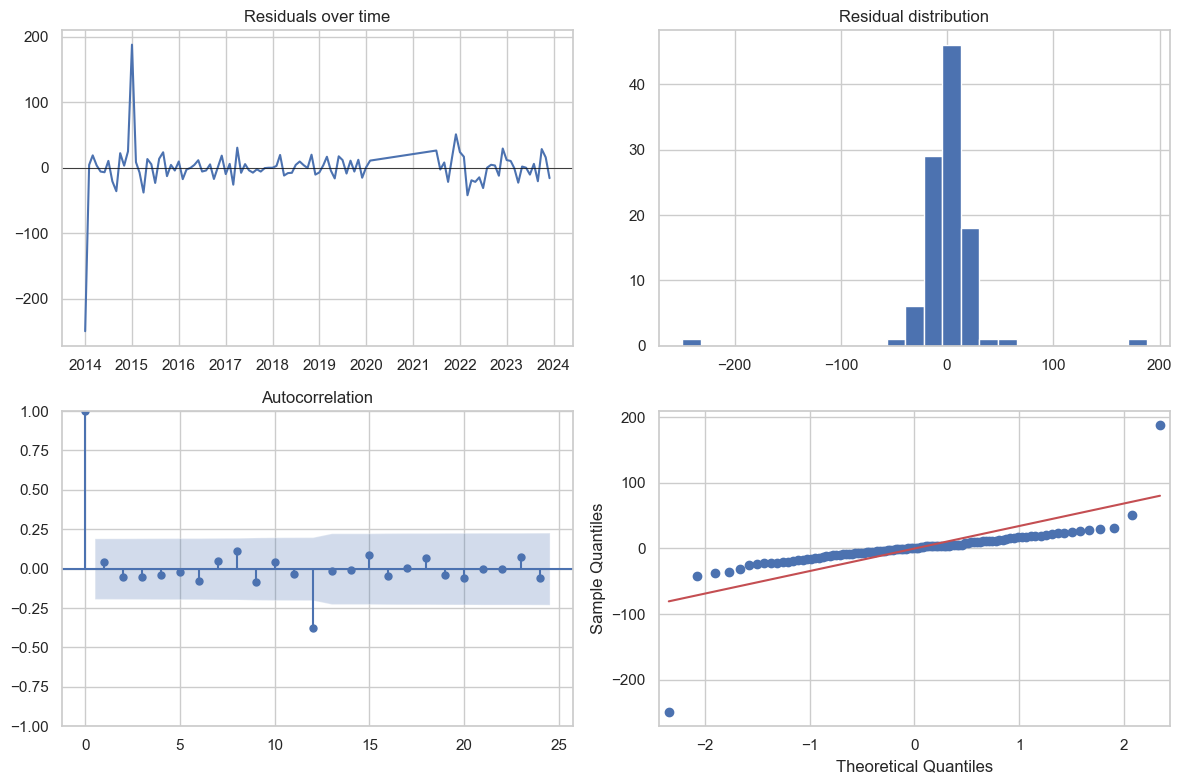

,lb_stat,lb_pvalue
6,1.663581,0.947898
12,21.579018,0.042518
18,23.424184,0.174812
24,25.284041,0.390459


Residual mean: -0.097
Residual std: 34.52


In [18]:
residuals = fitted_models["SARIMAX excl. COVID + exog"].resid

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0,0].plot(train_no_covid["date"], residuals.values)
axes[0,0].axhline(0, color="black", lw=0.5)
axes[0,0].set_title("Residuals over time")
axes[0,1].hist(residuals.dropna().values, bins=25, edgecolor="white")
axes[0,1].set_title("Residual distribution")
plot_acf(residuals.dropna(), lags=24, ax=axes[1,0])
sm.qqplot(residuals.dropna(), line="s", ax=axes[1,1])
plt.tight_layout()
plt.show()

lb = acorr_ljungbox(residuals.dropna(), lags=[6, 12, 18, 24], return_df=True)
display(lb)
print("Residual mean:", round(residuals.mean(), 3))
print("Residual std:", round(residuals.std(), 2))

The residual diagnostics for the SARIMAX excl. COVID + exog model are broadly acceptable. Ljung-Box passes comfortably at lags 6 (p = 0.95), 18 (p = 0.17), and 24 (p = 0.39), but is marginally significant at lag 12 (p = 0.043) — suggesting some residual seasonal autocorrelation that the (2,1,0)(0,1,1,12) specification does not fully capture.

The residual mean is essentially zero (−0.097), indicating no systematic bias. The residual std of 34.5 is moderate relative to the series mean (~350). The QQ plot shows moderate tail departures, likely driven by residuals near the edges of the COVID exclusion window.

## 8. Final holdout evaluation

The rolling CV in §5 selected **SARIMAX with COVID + exog** as the best all-weather model (avg RMSE 18.2). This section evaluates all models on the 24-month holdout (Jan 2024 – Dec 2025) — a purely post-recovery period that was not used for model selection.

Because the holdout is post-recovery, we should expect the excl. COVID model to perform well here even though it was not selected by the rolling CV. The comparison between the CV-selected model and the holdout-best model reveals an important tension between *all-weather robustness* and *regime-specific accuracy*.

In [19]:
# ── Holdout metrics ──
holdout_actual = final_holdout_df["passengers_thousands"].values
holdout_rows = []
for label, pred in predictions.items():
    holdout_rows.append({
        "model": label,
        "mae": round(mean_absolute_error(holdout_actual, pred), 1),
        "rmse": round(rmse(holdout_actual, pred), 1),
    })
holdout_results = pd.DataFrame(holdout_rows).sort_values("rmse").reset_index(drop=True)
display(holdout_results)

,model,mae,rmse
0,SARIMAX excl. COVID + exog,10.3,12.9
1,SARIMAX excl. COVID (no exog),14.6,17.6
2,SARIMAX with COVID + exog,18.1,22.4
3,SARIMAX with COVID (no exog),18.2,22.4
4,Holt-Winters,18.5,23.6
5,seasonal_naive,77.5,78.2
6,last_value,82.1,91.7


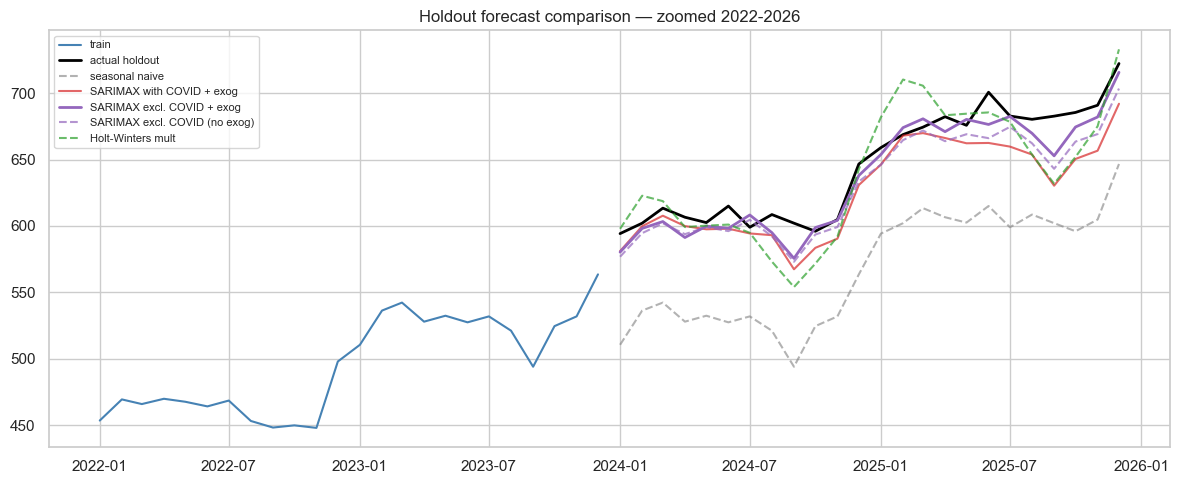

In [20]:
# Holdout visualization — zoomed 2022-2026
zoom_start = pd.Timestamp("2022-01-01")
train_zoom = train_df[train_df["date"] >= zoom_start]

plt.figure(figsize=(12, 5))
plt.plot(train_zoom["date"], train_zoom["passengers_thousands"], label="train", color="steelblue")
plt.plot(final_holdout_df["date"], final_holdout_df["passengers_thousands"],
         label="actual holdout", color="black", linewidth=2)
plt.plot(final_holdout_df["date"], seasonal_naive_pred,
         label="seasonal naive", linestyle="--", color="gray", alpha=0.6)
plt.plot(final_holdout_df["date"], predictions["SARIMAX with COVID + exog"],
         label="SARIMAX with COVID + exog", color="tab:red", alpha=0.7)
plt.plot(final_holdout_df["date"], predictions["SARIMAX excl. COVID + exog"],
         label="SARIMAX excl. COVID + exog", color="tab:purple", linewidth=2)
plt.plot(final_holdout_df["date"], predictions["SARIMAX excl. COVID (no exog)"],
         label="SARIMAX excl. COVID (no exog)", color="tab:purple", linestyle="--", alpha=0.7)
plt.plot(final_holdout_df["date"], pred_hw,
         label="Holt-Winters mult", color="tab:green", linestyle="--", alpha=0.7)
plt.legend(fontsize=8, loc="upper left")
plt.title("Holdout forecast comparison — zoomed 2022-2026")
plt.tight_layout()
plt.show()

### Sign tests on holdout

The sign tests compare models pairwise on a per-month basis. Since the holdout was not used for model selection, these tests carry full inferential weight as confirmatory evidence.

In [21]:
from scipy.stats import binomtest

errors = {name: np.abs(holdout_actual - pred) for name, pred in predictions.items()
          if name != "last_value"}

comparisons = [
    ("SARIMAX excl. COVID + exog", "seasonal_naive"),
    ("SARIMAX excl. COVID + exog", "SARIMAX with COVID + exog"),
    ("SARIMAX excl. COVID + exog", "Holt-Winters"),
    ("SARIMAX excl. COVID + exog", "SARIMAX excl. COVID (no exog)"),
    ("SARIMAX with COVID + exog", "SARIMAX with COVID (no exog)"),
    ("SARIMAX with COVID + exog", "seasonal_naive"),
]

for a, b in comparisons:
    wins_a = int((errors[a] < errors[b]).sum())
    n = int((errors[a] != errors[b]).sum())
    p = binomtest(wins_a, n, 0.5, alternative="greater").pvalue
    print(f"{a} vs {b}: {wins_a}/{n} months (p={p:.4f})")

SARIMAX excl. COVID + exog vs seasonal_naive: 24/24 months (p=0.0000)
SARIMAX excl. COVID + exog vs SARIMAX with COVID + exog: 17/24 months (p=0.0320)
SARIMAX excl. COVID + exog vs Holt-Winters: 15/24 months (p=0.1537)
SARIMAX excl. COVID + exog vs SARIMAX excl. COVID (no exog): 19/24 months (p=0.0033)
SARIMAX with COVID + exog vs SARIMAX with COVID (no exog): 12/24 months (p=0.5806)
SARIMAX with COVID + exog vs seasonal_naive: 24/24 months (p=0.0000)


The holdout results diverge sharply from the rolling CV selection:

**The excl. COVID + exog model dominates the holdout** (RMSE 12.9), beating the CV-selected with-COVID + exog (22.4) on 17/24 months (p = 0.032). This is not surprising — the holdout is entirely post-recovery, precisely the regime where excluding COVID from training produces cleaner parameter estimates.

**Exogenous variables help the excl. COVID model on the holdout** (RMSE 12.9 vs 17.6 no exog, 19/24 months, p = 0.003), even though no individual variable is significant (§6) and they hurt in rolling CV (§5). The holdout is long enough (24 months) that the diffuse collective signal aggregates into a meaningful improvement.

**Exogenous variables do not help the with-COVID model** on the holdout (22.4 vs 22.4, 12/24 months, p = 0.58) — the shock_dummy absorbs most of the signal and the remaining covariates are noise.

**The CV/holdout divergence is the central methodological finding.** The rolling CV optimizes for all-weather performance (including COVID-era folds), while the holdout reflects future post-recovery forecasting. Neither is "wrong" — the right choice depends on the forecasting objective:
- If another structural shock is plausible and the model must handle it, the **with-COVID + exog** model (CV-selected) is more robust.
- If the forecast horizon is firmly post-recovery, the **excl. COVID + exog** model delivers substantially better accuracy.

In production, a regime-aware strategy would be ideal: use the with-COVID model during crisis/recovery periods, and switch to the excl. COVID model once the series returns to baseline.

## Final remarks

All structured models substantially outperform the seasonal naive (RMSE 78 → 12–23). The rolling-origin CV selects **SARIMAX with COVID + exog** (avg RMSE 18.2) as the best all-weather model, while the holdout reveals that **SARIMAX excl. COVID + exog** (RMSE 12.9) is superior for post-recovery forecasting.

Key findings:

- **The CV/holdout divergence is informative, not a problem.** The rolling CV penalizes the excl. COVID model for failing on COVID-era folds (RMSE 54–65), while the holdout rewards it for clean post-recovery forecasting (RMSE 12.9). The two metrics answer different questions: "which model handles all regimes?" vs "which model forecasts best *now*?"

- **Exogenous variables carry value through `shock_dummy` only.** In the with-COVID model, shock_dummy (z = −21.4) and weather_severity (z = 2.4) are significant; nothing else. In the excl. COVID model, no individual variable is significant, and exogenous variables hurt in rolling CV. Yet they help on the holdout (p = 0.003), suggesting a diffuse collective signal that aggregates over 24 months.

- **Multiplicative seasonality remains the dominant structural signal.** Holt-Winters (RMSE 23.6 holdout, avg RMSE 23.6 rolling) is competitive without any exogenous variables — a log-transform of the SARIMAX target would likely close this gap.

- **auto_arima selects different orders** on full vs COVID-excluded data — (0,1,1)(1,1,0,12) vs (2,1,0)(0,1,1,12) — confirming that COVID changes the model structure.

**What I would do next:**
- **Fit SARIMAX on log-transformed passengers** to handle multiplicative seasonality natively — highest-priority extension
- **Implement a regime-aware production strategy**: with-COVID model during crisis/recovery, excl. COVID model in baseline regime
- **Sensitivity analysis on the COVID exclusion window** to verify the excl. COVID holdout result is not an artefact of the specific cutoff
- **Drop non-significant continuous exogenous variables** from the excl. COVID model and test whether the leaner specification improves rolling CV performance
- **Build an exogenous forecast pipeline** — in production, the SARIMAX requires future values of exogenous variables